In [1]:
import warnings
import math
from pathlib import Path

import jax
from jax import Array
from jax.tree_util import Partial
from jax import numpy as jnp

import dynamiqs as dq

from blueprint.qubits import Fluxonium, HarmonicOscillator
from blueprint.devices import Device
from blueprint.couplings import get_capacitive_coupling
from blueprint.util.index import get_branch_inds
from blueprint.util.quantum import to_denstiy_matrix


from matplotlib import pyplot as plt

/Users/varb2323/Projects/blueprint/.venv/lib/python3.12/site-packages/qutip/__init__.py:71: UserWarning: Runtime cython compilation does not work on Python 3.12.
  warnings.warn(


In [2]:
def get_figsize(
    columns: int = 1, fig_width=None, fig_height=None, width_scale=1.0, height_scale=1.0
):
    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf

    if columns not in [1, 2]:
        raise ValueError("Plotting in three-column style is not supported")

    MAX_HEIGHT = 8.0
    golden_ratio = 0.5 * (1 + math.sqrt(5))

    if not fig_width:
        fig_width = (
            3.4 if columns == 1 else 7
        )  # one-column width is ~8.6cm, double-column is ~17.8cm

    fig_height = fig_height or fig_width / golden_ratio  # height in inches

    if fig_height > MAX_HEIGHT:
        warnings.warn(
            "Figure height {} is too large, setting to {}"
            "inches instead".format(fig_height, MAX_HEIGHT)
        )

    width = fig_width * width_scale
    height = fig_height * height_scale
    figsize = (width, height)
    return figsize


def get_rc_params(**kwargs):
    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf
    params = {
        # "backend": "ps",
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "text.usetex": False,
        "font.family": "serif",
    }
    params.update(kwargs)
    return params

In [3]:
def rectangular_envelope(t: float | Array, /, pad_time: float, hold_time: float) -> Array:
    hold_times = (t > pad_time) & (t <= pad_time + hold_time)
    envelope = jnp.where(hold_times, 1, 0)
    return envelope

def readout_pulse(
    t: float,
    drive_amplitude: float | Array,
    drive_frequency: float | Array,
    pad_time: float,
    hold_time: float,
) -> float | Array: 
    envelope = rectangular_envelope(t, pad_time, hold_time)
    amplitude = drive_amplitude * jnp.sin(drive_frequency * t)
    result = envelope * amplitude
    return result

In [4]:
def get_hamiltonian(device):
    hamiltonian = device.get_hamiltonian()
    hamiltonian_arr = dq.constant(hamiltonian)

    drive_terms = device.get_drive_hamiltonian_terms()
    for prefactor, operator in drive_terms:
        modulated_arr = dq.modulated(prefactor, operator)
        hamiltonian_arr += modulated_arr

    return hamiltonian_arr

def get_jump_ops(device):
    jump_ops = list(device.get_jump_ops())
    if jump_ops:
        return jump_ops
    
    null_op = jnp.zeros((device.dim, device.dim))
    return [null_op]


In [5]:
# Set the options for the GPU use
USE_GPU: bool = False
DEVICE_IND: int = 0

USE_NETCDF4: bool = True

# Units
GHz = 2 * math.pi
MHz = 1e-3 * 2 * math.pi

ns = 1

# Set up environement
jax.config.update("jax_enable_x64", True)  # Double precision

Set up the notebook directory

In [6]:
notebook_dir = Path.cwd()

Define the fluxonium parameters

In [7]:
# Qubit parameters
QUBIT_LABEL = "fluxonium"
CHARGING_ENERGY: float = 1.0 * GHz
INDUCTIVE_ENERGY: float = 0.275 * GHz
JOSEPHSON_ENERGY: float = 5.0 * GHz
EXT_FLUX: float = 0.5 * 2 * math.pi
FOCK_CUTOFF: int = 1000
QUBIT_DIM: int = 5

Define the resonator parameters

In [8]:
RES_LABEL: str = "resonator"
RES_FREQ: float = 6.75 * GHz
RES_IMPEDANCE: float = 50.0
RES_DECAY_RATE: float = 2 * MHz
RES_THERMAL_PHOTONS: float = 0.0
RES_DIM: int = 5

Define the coupling strength between the fluxonium and the resonator

In [9]:
# Coupling strength
COUP_LABEL = "coupling"
COUP_STRENGTH = 100 * MHz

Set the readout drive parameters

In [10]:
DRIVE_AMPLITUDE: float = 2.5 * MHz  # Drive amplitude
PAD_TIME: float = 0 # Time before the pulse starts
HOLD_TIME: float = 250 * ns  # Time the pulse is on


In [11]:
fluxonium = Fluxonium(
    label=QUBIT_LABEL,
    charging_energy=CHARGING_ENERGY,
    inductive_energy=INDUCTIVE_ENERGY,
    josephson_energy=JOSEPHSON_ENERGY,
    ext_flux=EXT_FLUX,
    fock_cutoff=FOCK_CUTOFF,
)

fluxonium.diagonalize(QUBIT_DIM)

In [12]:
resonator = HarmonicOscillator.from_frequency(
    label=RES_LABEL,
    frequency=RES_FREQ,
    impedance=RES_IMPEDANCE,
    dim=RES_DIM,
    decay_rate=RES_DECAY_RATE,
    thermal_photons=RES_THERMAL_PHOTONS,
)

In [13]:
device = Device(fluxonium, resonator)

coupling_strength = COUP_STRENGTH / resonator.charge_zpf
coupling = get_capacitive_coupling(
    label=COUP_LABEL,
    system=fluxonium,
    coupled_system=resonator,
    coupling_strength=coupling_strength,
)
device.add_coupling(coupling)

In [14]:
energies, state_vecs = device.get_eigenstates()

ground_inds = jnp.argmax(jnp.abs(state_vecs[::RES_DIM]), axis=1)

raise_op = resonator.get_raise_op()
inds = get_branch_inds(state_vecs, raise_op, ground_inds)

energies = energies[inds]
state_vecs = state_vecs[:, inds]
states = jnp.einsum("ia,ja->aij", state_vecs, jnp.conj(state_vecs))

energies = energies.reshape(QUBIT_DIM, RES_DIM)
prod_dim  = QUBIT_DIM * RES_DIM
states = states.reshape(QUBIT_DIM, RES_DIM, prod_dim, prod_dim)


In [15]:
dressed_res_freq = energies[0, 1] - energies[0, 0]
shifted_res_freq = energies[1, 1] - energies[1, 0]
drive_frequency = 0.5 * (shifted_res_freq + dressed_res_freq)

In [16]:
drive_amplitude = DRIVE_AMPLITUDE / resonator.charge_zpf
partial_pulse = Partial(
    readout_pulse,
    drive_amplitude=drive_amplitude,
    drive_frequency=drive_frequency,
    pad_time=PAD_TIME,
    hold_time=HOLD_TIME,
)
resonator.add_charge_drive(label="readout_pulse", charge_pulse=partial_pulse)

In [17]:
save_times = jnp.linspace(0, 500, 100)

hamiltonian = get_hamiltonian(device)

jump_ops = list(resonator.get_jump_ops())

state_inds = [(0, 0), (1, 0)]
state_list = [states[qubit_ind, res_ind] for qubit_ind, res_ind in state_inds]
init_states = jnp.stack(state_list)

res_low_op = resonator.get_low_op()
res_number_op = resonator.get_number_op()

qubit_number_op = fluxonium.get_number_op()

branch_projectors = jnp.sum(states, axis=1)

qubit_inds = jnp.arange(QUBIT_DIM)
branch_number_op = jnp.einsum("i, ijk -> jk", qubit_inds, branch_projectors)

exp_ops = [res_low_op, res_number_op, qubit_number_op, branch_number_op]

for ind in range(QUBIT_DIM):
    exp_ops.append(branch_projectors[ind])

In [18]:
options=dq.Options(save_states=True, verbose=True)
solver = dq.solver.Tsit5(rtol=1e-8, atol=1e-8, max_steps=1000000)

In [19]:

result = dq.mesolve(
    hamiltonian,
    jump_ops, 
    init_states, 
    save_times, 
    exp_ops=exp_ops,
    solver=solver,
    options=options,   
    
)
print(result)

100.00%|██████████| [00:55<00:00,  1.82%/s]


==== MEResult ====
Solver   : Tsit5
States   : Array complex128 (2, 100, 25, 25) | 1.91 Mb
Expects  : Array complex128 (2, 9, 100) | 28.12 Kb
Infos    : avg. 180873.5 steps (180851.5 accepted, 22.0 rejected) | infos shape (2,)


In [20]:
if result.expects is None:
    raise ValueError("No expectation values found")

expect_values = result.expects

In [21]:

average_fields = expect_values[:, 0] 
rot_average_fields = average_fields * jnp.exp(1j * drive_frequency * save_times)

res_populations = jnp.real(expect_values[:, 1])
qubit_populations = jnp.real(expect_values[:, 2])
branch_populations = jnp.real(expect_values[:, 3])

ind_branch_populations = jnp.real(expect_values[:, 4:])

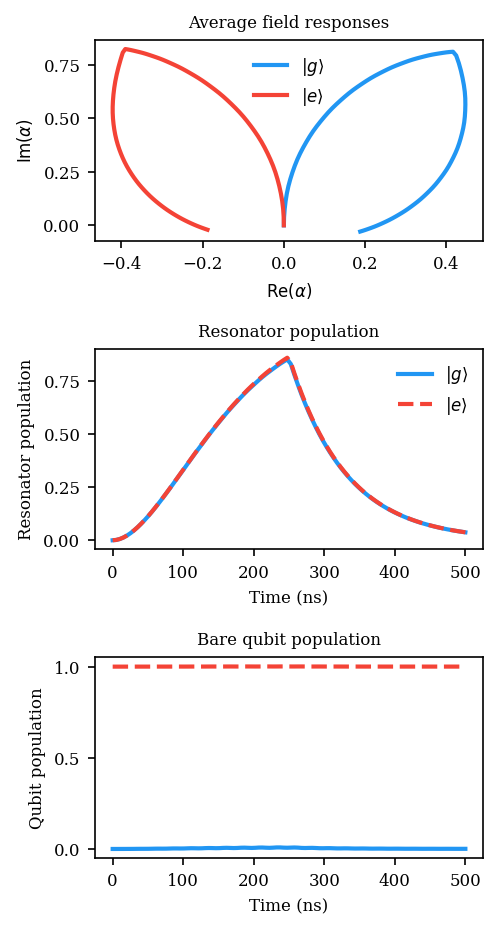

In [22]:
state_labels = ("g", "e")

colors = ("#2196f3", "#f44336")
linestyles = ("-", "--")

figsize = get_figsize(height_scale=3)
rc_params = get_rc_params()

with plt.rc_context(rc_params):
    fig, axs = plt.subplots(nrows=3, figsize=figsize, tight_layout=True, dpi=150)
    field_ax, res_ax, qubit_ax = axs

    for ind, state_label in enumerate(state_labels):
        label = f"$\\vert {state_label}\\rangle$"
        color = colors[ind]
        linestyle = linestyles[ind]

        state_field = rot_average_fields[ind]
        field_ax.plot(
            state_field.real,
            state_field.imag,
            label=label,
            color=color,
            linewidth=2,
        )

        res_population = res_populations[ind]
        res_ax.plot(
            save_times,
            res_population,
            label=label,
            color=color,
            linestyle=linestyle,
            linewidth=2,            
        )

        qubit_population = qubit_populations[ind]
        qubit_ax.plot(
            save_times,
            qubit_population,
            label=label,
            color=color,
            linestyle=linestyle,
            linewidth=2,
        )

    field_ax.set_title("Average field responses")
    field_ax.set_xlabel(r"$\mathrm{Re}(\alpha)$")
    field_ax.set_ylabel(r"$\mathrm{Im}(\alpha)$")
    field_ax.legend(frameon=False)

    res_ax.set_xlabel(r"Time (ns)")
    res_ax.set_ylabel(r"Resonator population")
    res_ax.set_title(r"Resonator population")
    res_ax.legend(frameon=False)

    qubit_ax.set_xlabel(r"Time (ns)")
    qubit_ax.set_ylabel(r"Qubit population")
    qubit_ax.set_title(r"Bare qubit population")
    res_ax.legend(frameon=False)

plt.show()

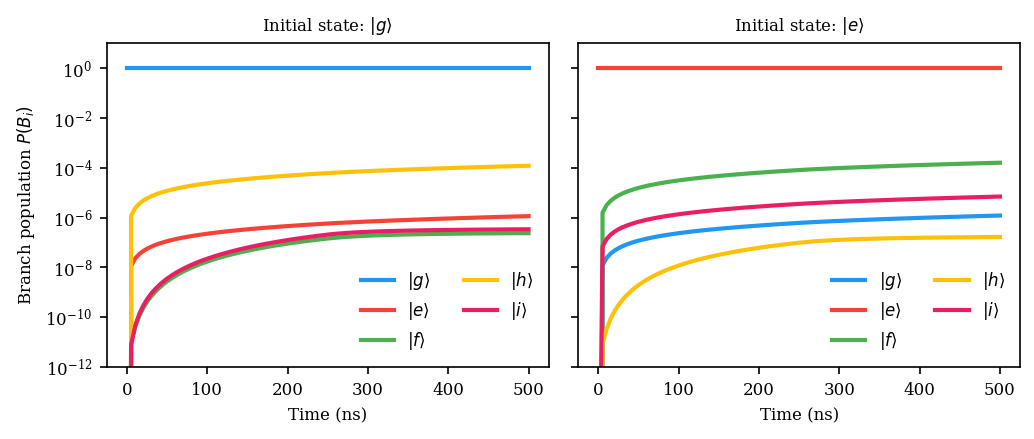

In [23]:
state_labels = ("g", "e")
state_inds = (0, 1)
branch_labels = ("g", "e", "f", "h", "i")

colors = ("#2196f3", "#f44336", "#4caf50", "#ffc107", "#e91e63")

figsize = get_figsize(columns=2, height_scale=0.7)
rc_params = get_rc_params()

with plt.rc_context(rc_params):
    fig, axs = plt.subplots(ncols=2, figsize=figsize, tight_layout=True, dpi=150, sharey=True)

    for ax, state_ind, state_label in zip(axs, state_inds, state_labels):
        for ind, branch_label in enumerate(branch_labels):
            label = f"$\\vert {branch_label} \\rangle$"
            color = colors[ind]

            branch_population = ind_branch_populations[state_ind, ind]
            ax.plot(
                save_times,
                branch_population,
                label=label,
                color=color,
                linewidth=2,            
            )
        subplot_title = f"Initial state: $\\vert {state_label} \\rangle$"
        ax.set_yscale("log")
        ax.set_title(subplot_title)
        ax.set_xlabel(r"Time (ns)")
        ax.set_ylim(1e-12, 10)
        ax.legend(frameon=False, ncols=2)

        if state_ind == 0:
            ax.set_ylabel(r"Branch population $P\left(B_{i}\right)$")
        

plt.show()

Performing a vectorized scan

In [26]:
DRIVE_AMPLITUDES = jnp.linspace(2, 5, 3) * MHz
drive_amplitudes = DRIVE_AMPLITUDES / resonator.charge_zpf

In [27]:
resonator.remove_drive("readout_pulse")

drive_amplitude = DRIVE_AMPLITUDE / resonator.charge_zpf
partial_pulse = Partial(
    readout_pulse,
    drive_amplitude=drive_amplitudes,
    drive_frequency=drive_frequency,
    pad_time=PAD_TIME,
    hold_time=HOLD_TIME,
)
resonator.add_charge_drive(label="readout_pulse", charge_pulse=partial_pulse)

In [28]:
hamiltonian = get_hamiltonian(device)

In [29]:
options = dq.Options(save_states=True, verbose=True)
solver = dq.solver.Tsit5(rtol=1e-8, atol=1e-8, max_steps=1000000)

In [30]:

result = dq.mesolve(
    hamiltonian,
    jump_ops, 
    init_states, 
    save_times, 
    exp_ops=exp_ops,
    solver=solver,
    options=options,   
    
)
print(result)

100.00%|██████████| [02:56<00:00,  1.76s/%]

==== MEResult ====
Solver   : Tsit5
States   : Array complex128 (3, 2, 100, 25, 25) | 5.72 Mb
Expects  : Array complex128 (3, 2, 9, 100) | 84.38 Kb
Infos    : avg. 188415.5 steps (188393.8333333333 accepted, 21.666666666666664 rejected) | infos shape (3, 2)


In [31]:
if result.expects is None:
    raise ValueError("No expectation values found")

expect_values = result.expects

In [32]:

average_fields = expect_values[:, :, 0] 
rot_average_fields = average_fields * jnp.exp(1j * drive_frequency * save_times)

res_populations = jnp.real(expect_values[:, :, 1])
qubit_populations = jnp.real(expect_values[:, :, 2])
branch_populations = jnp.real(expect_values[:, :, 3])

ind_branch_populations = jnp.real(expect_values[:, :, 4:])

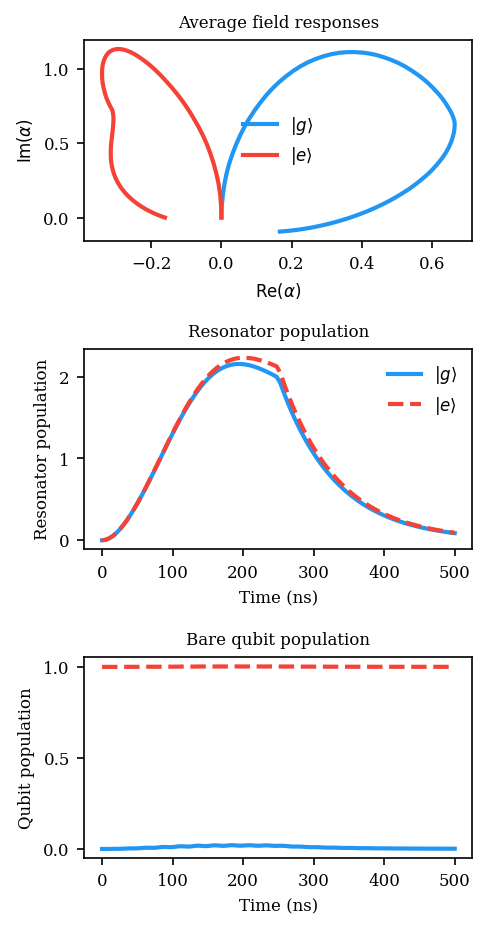

In [33]:
state_labels = ("g", "e")

drive_amp_ind = 2

colors = ("#2196f3", "#f44336")
linestyles = ("-", "--")

figsize = get_figsize(height_scale=3)
rc_params = get_rc_params()

with plt.rc_context(rc_params):
    fig, axs = plt.subplots(nrows=3, figsize=figsize, tight_layout=True, dpi=150)
    field_ax, res_ax, qubit_ax = axs

    for ind, state_label in enumerate(state_labels):
        label = f"$\\vert {state_label}\\rangle$"
        color = colors[ind]
        linestyle = linestyles[ind]

        state_field = rot_average_fields[drive_amp_ind, ind]
        field_ax.plot(
            state_field.real,
            state_field.imag,
            label=label,
            color=color,
            linewidth=2,
        )

        res_population = res_populations[drive_amp_ind, ind]
        res_ax.plot(
            save_times,
            res_population,
            label=label,
            color=color,
            linestyle=linestyle,
            linewidth=2,            
        )

        qubit_population = qubit_populations[drive_amp_ind, ind]
        qubit_ax.plot(
            save_times,
            qubit_population,
            label=label,
            color=color,
            linestyle=linestyle,
            linewidth=2,
        )

    field_ax.set_title("Average field responses")
    field_ax.set_xlabel(r"$\mathrm{Re}(\alpha)$")
    field_ax.set_ylabel(r"$\mathrm{Im}(\alpha)$")
    field_ax.legend(frameon=False)

    res_ax.set_xlabel(r"Time (ns)")
    res_ax.set_ylabel(r"Resonator population")
    res_ax.set_title(r"Resonator population")
    res_ax.legend(frameon=False)

    qubit_ax.set_xlabel(r"Time (ns)")
    qubit_ax.set_ylabel(r"Qubit population")
    qubit_ax.set_title(r"Bare qubit population")
    res_ax.legend(frameon=False)

plt.show()